In [ ]:
# Since I ran this notebook on google colab, I had to zip and upload images to google colab. Unzipping them
!unzip images_compressed.zip

Streaming output truncated to the last 5000 lines.
  inflating: images_compressed/2126322b-b4eb-4410-988a-9261155c017a.jpg  
  inflating: images_compressed/2135ff47-f57e-4252-8fb8-5f89f1f757c4.jpg  
  inflating: images_compressed/214245bb-8308-4981-be30-4f82e4766607.jpg  
  inflating: images_compressed/2153199f-0a48-4334-bb12-51e07486b5c0.jpg  
  inflating: images_compressed/21531a69-d7f0-4d77-a2d9-a4269652344e.jpg  
  inflating: images_compressed/215d49b8-c7b7-4ce0-979c-9f9edf1065d7.jpg  
  inflating: images_compressed/2160a577-406a-4812-ada2-2a3cb30c2ba8.jpg  
  inflating: images_compressed/216ddb53-2a80-4218-99b0-b5b721744fc3.jpg  
  inflating: images_compressed/216f2433-a511-4834-9b8c-d01bc926d5d4.jpg  
  inflating: images_compressed/2174d585-e8cf-43ce-bb61-de1567c74fd5.jpg  
  inflating: images_compressed/21845140-b1e3-4344-b836-60e1d4b09311.jpg  
  inflating: images_compressed/2199f7e3-4474-4ebc-aeff-4da50d2e49d5.jpg  
  inflating: images_compressed/21a06a8f-583d-40c5-b5f8-2b735a

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns
import tensorflow
from tensorflow import keras
from keras.layers import Dense, Conv2D, BatchNormalization, MaxPooling2D, Input, Flatten,\
Dropout
from keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

In [3]:
# create dataframe after reading records from images.csv file. Also adding a new field label_indx, which is numerical representation of string index.
df_image=pd.read_csv('images.csv')
label_indx={label:indx for indx,label in enumerate(df_image['label'].unique())}
df_image['label_indx']=df_image['label'].map(label_indx)
df_image['image_path']=df_image['image'].apply(lambda x: 'images_compressed/'+x+'.jpg')
df_image.head()

,image,sender_id,label,kids,label_indx,image_path
0,4285fab0-751a-4b74-8e9b-43af05deee22,124,Not sure,False,0,images_compressed/4285fab0-751a-4b74-8e9b-43af...
1,ea7b6656-3f84-4eb3-9099-23e623fc1018,148,T-Shirt,False,1,images_compressed/ea7b6656-3f84-4eb3-9099-23e6...
2,00627a3f-0477-401c-95eb-92642cbe078d,94,Not sure,False,0,images_compressed/00627a3f-0477-401c-95eb-9264...
3,ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa,43,T-Shirt,False,1,images_compressed/ea2ffd4d-9b25-4ca8-9dc2-bd27...
4,3b86d877-2b9e-4c8b-a6a2-1d87513309d0,189,Shoes,False,2,images_compressed/3b86d877-2b9e-4c8b-a6a2-1d87...


In [4]:
# Simply printing label and corresponding lable_indx values
df_image[['label','label_indx']].drop_duplicates()

,label,label_indx
0,Not sure,0
1,T-Shirt,1
4,Shoes,2
5,Shorts,3
6,Shirt,4
8,Pants,5
10,Skirt,6
13,Other,7
16,Top,8
18,Outwear,9


In [5]:
# Splitting into training and testing
train_df, test_df = train_test_split(df_image, test_size=0.2, stratify=df_image["label_indx"],
random_state=7)

In [6]:
def load_image(path, label):
    image = tensorflow.io.read_file(path)
    image = tensorflow.image.decode_jpeg(image, channels=3)
    image = tensorflow.image.resize(image, (224, 224))
    image = image / 255.0   # normalize
    return image, label

# Converts dataframe into tensorflow dataset. Also club images into batch of 32 images in each batch.
def create_tf_dataset(df):
    dataset = tensorflow.data.Dataset.from_tensor_slices((df['image_path'], df['label_indx']))
    dataset = dataset.map(load_image)
    dataset = dataset.batch(32)
    return dataset

train_df = create_tf_dataset(train_df)
test_df = create_tf_dataset(test_df)


In [ ]:
print(type(train_df))
for imgs, labels in train_df.take(1):
    print(labels)

<class 'tensorflow.python.data.ops.batch_op._BatchDataset'>
tf.Tensor(
[14  3 12  0  0  1 12 10  5 19  0  0  1 12 10  9  9  5 13 12  5  5  5 17
 12  1  2 10  5  2  9  5], shape=(32,), dtype=int64)


<Axes: xlabel='label'>

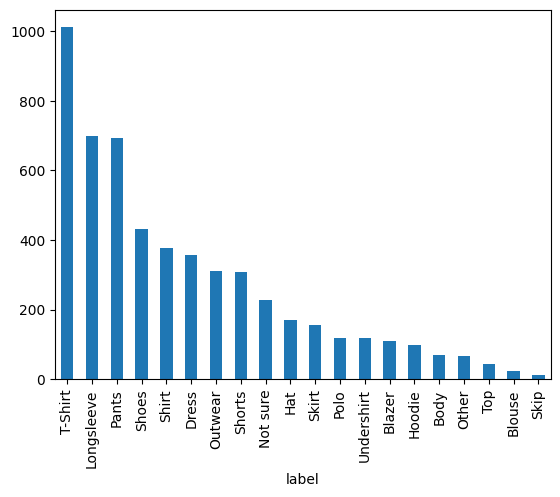

In [ ]:
# Printing different classes and their numbers in the dataset
df_image['label'].value_counts().plot(kind='bar')

In [ ]:
from collections import Counter

label_counts = Counter()
total_samples = 0

for images, labels in train_df:
    labels_np = labels.numpy()
    label_counts.update(labels_np)
    total_samples += len(labels_np)

# Print counts
print("Counts:", label_counts)

class_ratios = {label: total_samples / count for label, count in label_counts.items()}
print("Class Ratios:", class_ratios)
# Print ratios
for label, count in label_counts.items():
    print(f"{label}: {count / total_samples:.3f}")

Counts: Counter({np.int64(1): 809, np.int64(12): 559, np.int64(5): 554, np.int64(2): 345, np.int64(4): 302, np.int64(10): 286, np.int64(9): 250, np.int64(3): 246, np.int64(0): 182, np.int64(14): 137, np.int64(6): 124, np.int64(15): 96, np.int64(13): 94, np.int64(19): 87, np.int64(17): 80, np.int64(11): 55, np.int64(7): 54, np.int64(8): 34, np.int64(16): 18, np.int64(18): 10})
Class Ratios: {np.int64(14): 31.547445255474454, np.int64(3): 17.56910569105691, np.int64(12): 7.731663685152057, np.int64(0): 23.747252747252748, np.int64(1): 5.342398022249691, np.int64(10): 15.111888111888112, np.int64(5): 7.8014440433212995, np.int64(19): 49.67816091954023, np.int64(9): 17.288, np.int64(13): 45.97872340425532, np.int64(17): 54.025, np.int64(2): 12.527536231884058, np.int64(15): 45.020833333333336, np.int64(7): 80.03703703703704, np.int64(4): 14.311258278145695, np.int64(6): 34.854838709677416, np.int64(16): 240.11111111111111, np.int64(11): 78.58181818181818, np.int64(8): 127.11764705882354, n

In [ ]:
# Creating a dictionary where key is label_indx and value is label value which is string
label_dict=dict(zip(df_image['label_indx'],df_image['label']))
display(label_dict)

{0: 'Not sure',
 1: 'T-Shirt',
 2: 'Shoes',
 3: 'Shorts',
 4: 'Shirt',
 5: 'Pants',
 6: 'Skirt',
 7: 'Other',
 8: 'Top',
 9: 'Outwear',
 10: 'Dress',
 11: 'Body',
 12: 'Longsleeve',
 13: 'Undershirt',
 14: 'Hat',
 15: 'Polo',
 16: 'Blouse',
 17: 'Hoodie',
 18: 'Skip',
 19: 'Blazer'}

In [ ]:
# Display two images from each class or category
def display_image(image, label):
    plt.imshow(image.numpy())
    plt.axis("off")
    plt.title(f"Label: {label_dict[label.numpy()]}")
    plt.show()

img_count_dict={key:0 for key in label_dict.keys()}
print(img_count_dict)
# Displaying 2 images of each category
ds = train_df.unbatch()
cntr=0

for image, label in ds:
    key = int(label.numpy())
    if img_count_dict.get(key)<2 :
        img_count_dict[key] = img_count_dict.get(key) + 1
        cntr = cntr+1
        display_image(image, label)

    if all(value > 2 for value in img_count_dict.values()):
        break

display(cntr)
print(img_count_dict)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Creating simple CNN model.
# Simple CNN model
# CNN Model
simple_cnn_model = Sequential()
simple_cnn_model.add(Input(shape=(224,224,3), name='input_layer'))

simple_cnn_model.add(Conv2D(128,kernel_size=(3,3), padding='valid',activation='relu', name='conv_1'))
simple_cnn_model.add(BatchNormalization())
simple_cnn_model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid',name='maxpool_1'))

simple_cnn_model.add(Conv2D(256,kernel_size=(3,3), padding='valid',activation='relu', name='conv_2'))
simple_cnn_model.add(BatchNormalization())
simple_cnn_model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid',name='maxpool_2'))

# simple_cnn_model.add(Conv2D(256,kernel_size=(3,3), padding='valid',activation='relu', name='conv_3'))
# simple_cnn_model.add(BatchNormalization())
# simple_cnn_model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid',name='maxpool_3'))

simple_cnn_model.add(Flatten())

simple_cnn_model.add(Dense(256, activation='relu', name='ann_hidden_1'))
#simple_cnn_model.add(Dropout(.1))

#simple_cnn_model.add(Dense(128, activation='relu', name='ann_hidden_2'))
#simple_cnn_model.add(Dropout(.1))

simple_cnn_model.add(Dense(20, activation='softmax', name='output_layer'))

print(simple_cnn_model.summary())
simple_cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])
# Early stopping for all models
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
class_weights = class_ratios

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 222, 222, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 111, 111, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 109, 109, 256)  │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 54, 54, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 746496)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ann_hidden_1 (Dense)            │ (None, 256)            │   191,103,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191,408,660 (730.17 MB)

 Trainable params: 191,407,892 (730.16 MB)

 Non-trainable params: 768 (3.00 KB)

None


In [ ]:
simple_cnn_model_history=simple_cnn_model.fit(train_df, epochs=50, validation_data=test_df, verbose=1, callbacks=[early_stop])

Epoch 1/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 71s 388ms/step - accuracy: 0.1728 - loss: 82.3946 - val_accuracy: 0.1702 - val_loss: 2.9517
Epoch 2/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 36s 266ms/step - accuracy: 0.2298 - loss: 2.9512 - val_accuracy: 0.2165 - val_loss: 13.3563
Epoch 3/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 37s 275ms/step - accuracy: 0.2420 - loss: 2.7439 - val_accuracy: 0.2498 - val_loss: 15.3674
Epoch 4/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 37s 276ms/step - accuracy: 0.2510 - loss: 2.6640 - val_accuracy: 0.2276 - val_loss: 3.2054
Epoch 5/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 38s 280ms/step - accuracy: 0.2422 - loss: 2.7976 - val_accuracy: 0.2285 - val_loss: 29.0238
Epoch 6/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 38s 282ms/step - accuracy: 0.2460 - loss: 2.7105 - val_accuracy: 0.1869 - val_loss: 2.7241
Epoch 7/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 40s 292ms/step - accuracy: 0.2381 - loss: 2.6274 - val_accuracy: 0.2257 - val_loss: 2.6156
Epoch 8/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 38s 282ms/step - accuracy: 0.2501 - los

In [ ]:
# Functions to plot accuracy and loss graphs
def draw_accuracy_plot(history):
    plt.plot(history.history['accuracy'],color='red', label='train')
    plt.plot(history.history['val_accuracy'],color='green', label='validation')
    plt.legend()
    plt.title('Accuracy')
    plt.show()

def draw_val_plot(history):
    plt.plot(history.history['loss'],color='red', label='train')
    plt.plot(history.history['val_loss'],color='green', label='validation')
    plt.legend()
    plt.title('Loss')
    plt.show()

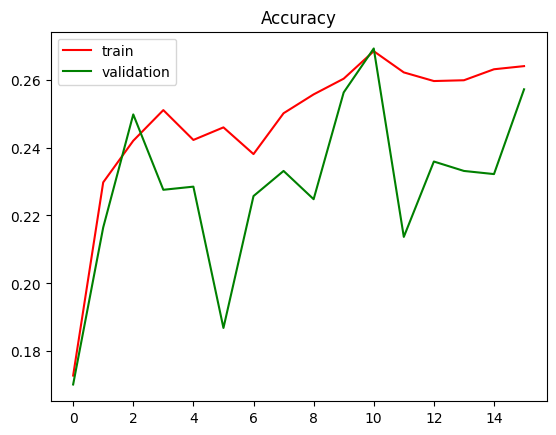

In [ ]:
draw_accuracy_plot(simple_cnn_model_history)

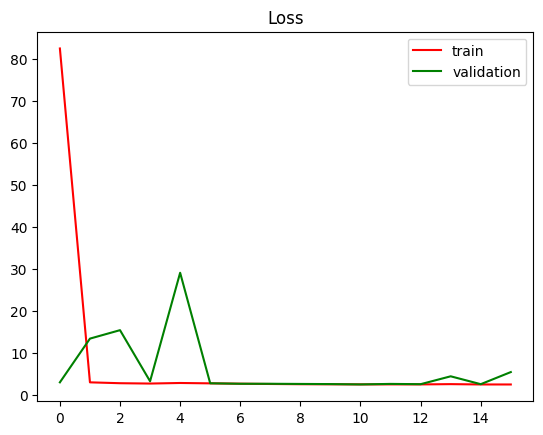

In [ ]:
draw_val_plot(simple_cnn_model_history)

In [ ]:
# Function to calculate accuracy, confusion matrix and classification report

from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report

def print_metrics(data_ds, model, data_set_type):
    y_true = []
    y_pred = []

    for X_batch, y_batch in data_ds:
        y_pred_batch = model.predict(X_batch, verbose=0)
        y_pred_batch = np.argmax(y_pred_batch, axis=1)

        y_pred.extend(y_pred_batch)
        y_true.extend(y_batch.numpy().ravel())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    #display(f"y_true: {y_true}")
    #display(f"y_pred: {y_pred}")

    print(f"Accuracy: {data_set_type}", accuracy_score(y_true, y_pred))
    print(f"\nConfusion Matrix: {data_set_type}\n", confusion_matrix(y_true, y_pred))
    print(f"\nClassification Report: {data_set_type}\n", classification_report(y_true, y_pred))


In [ ]:
print_metrics(test_df, simple_cnn_model,'test')

Accuracy: test 0.26919518963922295

Confusion Matrix: test
 [[  0  46   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0 201   0   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0  86   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0  61   0   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0  75   0   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0  47   0   0   0  90   0   0   0   0   0   0   1   0   0   0   0   0
    0   0]
 [  0  31   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0  13   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0   9   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0  62   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0  71   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print_metrics(train_df, simple_cnn_model,'train')

Accuracy: train 0.2716335030078667

Confusion Matrix: train
 [[  1 181   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0 803   0   0   2   4   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0 344   0   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0 242   0   2   0   2   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0 302   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0 195   0   0   0 359   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0 124   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0  54   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0  33   0   0   0   0   0   0   1   0   0   0   0   0   0   0   0   0
    0   0]
 [  0 249   0   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0 283   0   0   0   0   0   0   0   0   3   0   0   0   0   0   0   0
    0   0]
 [  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Transfer learning using VGG16
from tensorflow.keras.applications import VGG16
def get_vgg16_transferlearning_model():
    vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
    vgg16_base.trainable = False

    model = Sequential()
    model.add(vgg16_base)
    model.add(Flatten())
    model.add(Dense(128, activation='relu', name='ann_hidden_1'))
    model.add(Dropout(.1))
    model.add(Dense(20, activation='softmax', name='output_layer'))

    return model

vgg16_transferlearning_model = get_vgg16_transferlearning_model()
vgg16_transferlearning_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ann_hidden_1 (Dense)            │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,928,660 (68.39 MB)

 Trainable params: 3,213,972 (12.26 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
vgg16_transferlearning_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
metrics=['accuracy'])
vgg16_transferlearning_model_history=vgg16_transferlearning_model.fit(train_df, epochs=30, validation_data=test_df
                                                                      ,
verbose=1, callbacks=[early_stop])

Epoch 1/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 70s 387ms/step - accuracy: 0.5481 - loss: 1.6859 - val_accuracy: 0.6346 - val_loss: 1.2507
Epoch 2/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 34s 247ms/step - accuracy: 0.7254 - loss: 0.9370 - val_accuracy: 0.7225 - val_loss: 0.9724
Epoch 3/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 34s 249ms/step - accuracy: 0.7911 - loss: 0.6647 - val_accuracy: 0.7216 - val_loss: 0.9789
Epoch 4/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 33s 245ms/step - accuracy: 0.8637 - loss: 0.4650 - val_accuracy: 0.6698 - val_loss: 1.1665
Epoch 5/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 34s 249ms/step - accuracy: 0.8769 - loss: 0.3976 - val_accuracy: 0.6966 - val_loss: 1.1182
Epoch 6/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 34s 250ms/step - accuracy: 0.9033 - loss: 0.3214 - val_accuracy: 0.7308 - val_loss: 1.0484
Epoch 7/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 34s 248ms/step - accuracy: 0.9306 - loss: 0.2409 - val_accuracy: 0.7484 - val_loss: 0.9929
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.


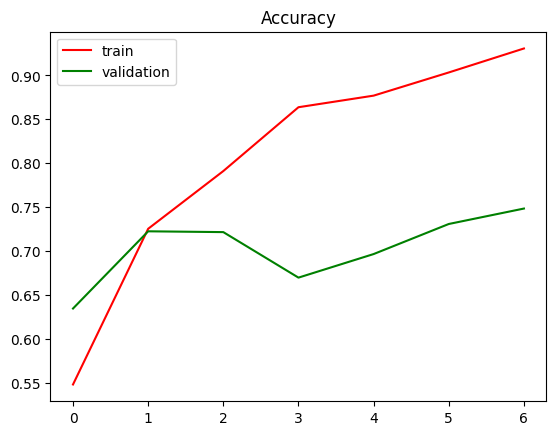

In [ ]:
draw_accuracy_plot(vgg16_transferlearning_model_history)

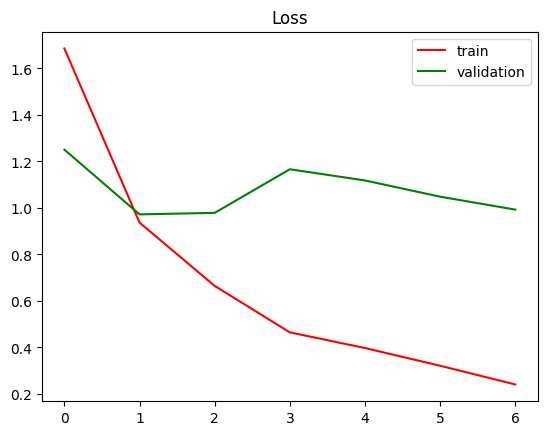

In [ ]:
draw_val_plot(vgg16_transferlearning_model_history)

In [ ]:
print_metrics(test_df, vgg16_transferlearning_model,'test')

Accuracy: test 0.7224791859389454

Confusion Matrix: test
 [[  3  14   1   1   2   2   2   0   0   3   3   0  12   3   0   0   0   0
    0   0]
 [  0 185   0   0   2   0   0   0   0   0   3   0  10   1   1   0   0   0
    0   0]
 [  0   0  86   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  2   0   0  51   0   3   5   0   0   0   0   0   0   1   0   0   0   0
    0   0]
 [  3   5   0   0  41   1   0   0   0   2   1   0  19   1   1   0   0   1
    0   1]
 [  0   2   0   3   0 131   0   0   0   1   1   0   0   0   0   0   0   0
    0   0]
 [  1   0   0   1   0   0  27   0   0   0   2   0   0   0   0   0   0   0
    0   0]
 [  0   3   0   0   0   0   0   0   0   3   0   0   4   3   0   0   0   0
    0   0]
 [  0   3   0   0   0   0   0   0   0   0   0   0   0   5   0   0   0   1
    0   0]
 [  2   0   0   0   1   0   0   0   0  27   2   0  19   1   1   0   0   9
    0   0]
 [  0  23   0   0   0   0   2   0   0   0  44   0   2   0   0   0   0   0
    0   0]
 [  0 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print_metrics(train_df, vgg16_transferlearning_model,'train')

Accuracy: train 0.8301712170291532

Confusion Matrix: train
 [[ 54  40   2   3   7   5   2   0   0   0  18   0  32   8   5   0   0   1
    0   5]
 [  0 799   0   0   0   0   0   0   0   0   1   0   5   4   0   0   0   0
    0   0]
 [  0   0 343   2   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0   0   1 224   0  16   3   0   0   0   0   1   1   0   0   0   0   0
    0   0]
 [  3  13   0   0 207   2   0   0   0   1   1   0  73   1   0   1   0   0
    0   0]
 [  0   2   0   6   0 543   1   0   0   0   0   0   1   0   0   0   0   1
    0   0]
 [  1   2   0   1   0   1 109   0   0   0   8   0   1   1   0   0   0   0
    0   0]
 [  0   5   0   1   4   6   1   3   0   6   5   2  14   4   0   0   0   2
    0   1]
 [  1   5   1   0   0   0   0   0  12   0   2   0   1  12   0   0   0   0
    0   0]
 [  4   2   0   0   3   0   1   0   0 170   5   0  48   1   1   0   0  12
    0   3]
 [  0  29   2   0   0   1   6   0   0   0 232   0  13   3   0   0   0   0
    0   0]
 [  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Transfer learning using ResNet50
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

def get_resnet50_transferlearning_model():
    resnet50_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
    )

    # Freeze base model
    resnet50_base.trainable = False

    # Build transfer learning model
    model = Sequential()
    model.add(resnet50_base)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(128, activation='relu', name='ann_hidden_1'))
    model.add(Dense(20, activation='softmax'))   # 20 classes

    # Compile
    optimizer_adam = Adam(learning_rate=1e-4)
    model.compile(
        optimizer=optimizer_adam,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

resnet50_transferlearning_model = get_resnet50_transferlearning_model()
resnet50_transferlearning_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ann_hidden_1 (Dense)            │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,852,564 (90.99 MB)

 Trainable params: 264,852 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
resnet50_transferlearning_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
metrics=['accuracy'])


In [ ]:
resnet50_transferlearning_model_history=resnet50_transferlearning_model.fit(train_df, epochs=50,
validation_data=test_df, verbose=1, callbacks=[early_stop])

Epoch 1/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 41s 212ms/step - accuracy: 0.1994 - loss: 2.6067 - val_accuracy: 0.2081 - val_loss: 2.5376
Epoch 2/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 16s 118ms/step - accuracy: 0.2406 - loss: 2.5156 - val_accuracy: 0.2331 - val_loss: 2.4873
Epoch 3/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - accuracy: 0.2615 - loss: 2.4580 - val_accuracy: 0.2562 - val_loss: 2.4479
Epoch 4/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - accuracy: 0.2751 - loss: 2.4147 - val_accuracy: 0.2720 - val_loss: 2.4178
Epoch 5/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - accuracy: 0.2876 - loss: 2.3797 - val_accuracy: 0.2784 - val_loss: 2.3899
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


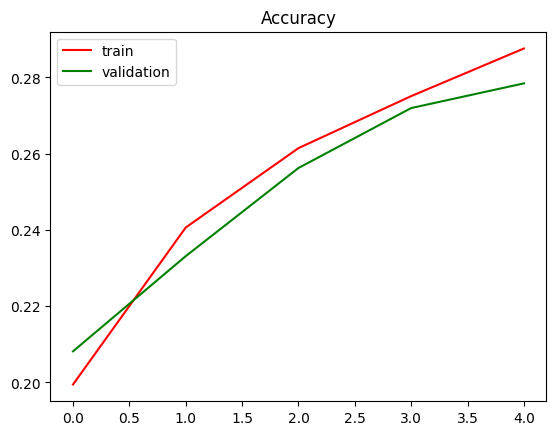

In [ ]:
draw_accuracy_plot(resnet50_transferlearning_model_history)

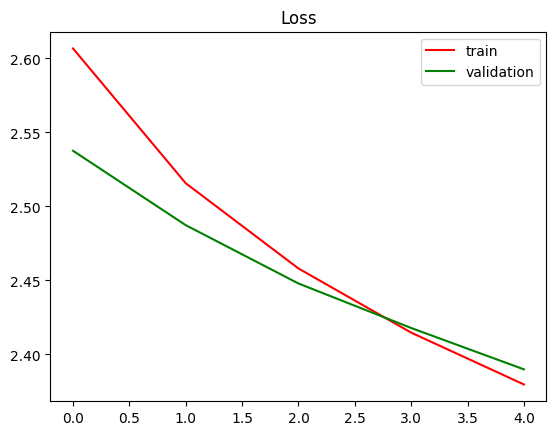

In [ ]:
draw_val_plot(resnet50_transferlearning_model_history)

In [ ]:
print_metrics(test_df, resnet50_transferlearning_model,'test')

Accuracy: test 0.20814061054579094

Confusion Matrix: test
 [[  0  45   0   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0 200   0   0   0   2   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0  76   0   0   0  10   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0  61   0   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0  73   0   0   0   3   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0 113   0   0   0  25   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0  31   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0  13   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0   8   0   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0  62   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0  70   0   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print_metrics(train_df, resnet50_transferlearning_model,'train')

Accuracy: train 0.21332716335030077

Confusion Matrix: train
 [[  0 178   0   0   0   4   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0 804   0   0   0   5   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0 323   0   0   0  21   0   0   0   0   1   0   0   0   0   0   0   0
    0   0]
 [  0 241   0   0   0   5   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0 298   0   0   0   4   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0 437   0   0   0 117   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0 123   0   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0  54   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0  34   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0 244   0   0   0   5   0   0   0   0   1   0   0   0   0   0   0   0
    0   0]
 [  0 277   0   0   0   8   0   0   0   0   1   0   0   0   0   0   0   0
    0   0]
 [ 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Since size of images became almost 1 GB after data augmentation, I copied zip file to google drive and copied zip file to google colab
# server from there
!cp "/content/drive/MyDrive/Colab_Notebooks/images_compressed_2.zip" "/content/"

In [ ]:
!unzip images_compressed_2.zip

Streaming output truncated to the last 5000 lines.
  inflating: images_compressed_2/aug_cb24db34-d06c-4671-89a7-7f5e5eee7cdc_676.jpg  
  inflating: images_compressed_2/aug_cb24db34-d06c-4671-89a7-7f5e5eee7cdc_678.jpg  
  inflating: images_compressed_2/aug_cb24db34-d06c-4671-89a7-7f5e5eee7cdc_816.jpg  
  inflating: images_compressed_2/aug_cb24db34-d06c-4671-89a7-7f5e5eee7cdc_831.jpg  
  inflating: images_compressed_2/aug_cb24db34-d06c-4671-89a7-7f5e5eee7cdc_872.jpg  
  inflating: images_compressed_2/aug_cb24db34-d06c-4671-89a7-7f5e5eee7cdc_883.jpg  
  inflating: images_compressed_2/aug_cb2533ac-c01d-4efc-bf0d-64894a088b11_195.jpg  
  inflating: images_compressed_2/aug_cb2533ac-c01d-4efc-bf0d-64894a088b11_255.jpg  
  inflating: images_compressed_2/aug_cb2533ac-c01d-4efc-bf0d-64894a088b11_468.jpg  
  inflating: images_compressed_2/aug_cb2533ac-c01d-4efc-bf0d-64894a088b11_649.jpg  
  inflating: images_compressed_2/aug_cb2533ac-c01d-4efc-bf0d-64894a088b11_714.jpg  
  inflating: images_compr

In [7]:
# Creating label_short_fall_count which contains number of entries for a class which are short than compared to majority class count.
label_counts=df_image['label_indx'].value_counts().to_dict()
majority_class_count=max(label_counts.values())
label_short_fall_count={key:majority_class_count-count for key,count in label_counts.items()}
print(label_short_fall_count)

{1: 0, 12: 312, 5: 319, 2: 580, 4: 633, 10: 654, 9: 699, 3: 703, 0: 783, 14: 840, 6: 856, 15: 891, 13: 893, 19: 902, 17: 911, 11: 942, 7: 944, 8: 968, 16: 988, 18: 999}


In [ ]:
# I ran this cell to generate images on local laptop and uploaded them to google drive for processing.
# Code to generate images.
import cv2
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

df_image_2=df_image.copy()
new_rows = [] # This list keeps track of all newly created images

datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Method to create images
def augment_and_save(img, datagen, save_path):
    aug_iter = datagen.flow(img, batch_size=1)
    aug_img = next(aug_iter)[0].astype('uint8')
    cv2.imwrite(save_path, aug_img)

for cls in label_short_fall_count.keys():

    required_images = label_short_fall_count[cls] # Return how many images for a particular class we need to create.
    if required_images == 0:
        print(f"Class {cls} is already balanced. Skipping augmentation.")
        continue

    images_df = df_image_2[df_image_2['label_indx'] == cls] # Select all images already present for particular class only.
    count = 0 # keeps track number of images created so far. Ideally required_images + count = number of images of majority class.

    print(f"Augmenting class {cls} with {required_images} images.")
    while count < required_images: # iterate as many times as number of images for a particular class to be created.
        single_image_df=images_df.sample(n=1) # Select one image of a particular class randomly, from available images.
        img=single_image_df['image_path'].values[0]
        img = cv2.imread(img)

        if img is None:
            continue

        img = np.expand_dims(img, axis=0)
        new_name = f"aug_{single_image_df['image'].values[0].split('.')[0]}_{count}" # All generated image starts with 'aug' literal
        save_path = os.path.join("images_compressed_2", new_name+".jpg")
        augment_and_save(img, datagen, save_path)

        new_rows.append({
                'image': new_name,
                'image_path': save_path,
                'label_indx': cls,
                'label': label_dict[cls]
            })
        count += 1

        # temp condition for testing remove it.
        # if count>0:
        #     break

    print(f"Finished augmenting class {cls}. Total augmented images: {count}")

print(f"Total new images added: {len(new_rows)}")
df_new = pd.DataFrame(new_rows) # All newly generated images are in new_rows. Create a new dataframe out of it.
df_image_2 = pd.concat([df_image_2, df_new], ignore_index=True) # create df_image_2 dataframe which has original as well as newly generated images.

In [ ]:
# We can delete this if not required to load augmented images. This line is needed for google colab. Since we created images on local laptop
# then uploaded to google colab, we just need to read images on google colab.
pd.set_option('display.max_colwidth', None) # Added to display full path of the image
df_image_2=pd.read_csv('df_image_2.csv')
df_image_2['image_path']

,image_path
0,images_compressed_2/4285fab0-751a-4b74-8e9b-43af05deee22.jpg
1,images_compressed_2/ea7b6656-3f84-4eb3-9099-23e623fc1018.jpg
2,images_compressed_2/00627a3f-0477-401c-95eb-92642cbe078d.jpg
3,images_compressed_2/ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa.jpg
4,images_compressed_2/3b86d877-2b9e-4c8b-a6a2-1d87513309d0.jpg
...,...
20215,images_compressed_2/aug_c60e486d-10ed-4f64-abab-5bb698c736dd_994.jpg
20216,images_compressed_2/aug_b739894c-5385-4b5d-a06f-26d57780161f_995.jpg
20217,images_compressed_2/aug_b739894c-5385-4b5d-a06f-26d57780161f_996.jpg
20218,images_compressed_2/aug_d028580f-9a98-4fb5-a6c9-5dc362ad3f09_997.jpg


In [ ]:
# Some testing stuff
!ls -lhtr images_compressed_2\29ecb21e-56b6-4c27-b9a9-fd5905adb951.jpg


ls: cannot access 'images_compressed_229ecb21e-56b6-4c27-b9a9-fd5905adb951.jpg': No such file or directory


In [ ]:
df_image_2[['label','label_indx']].drop_duplicates()

,label,label_indx
0,Not sure,0
1,T-Shirt,1
4,Shoes,2
5,Shorts,3
6,Shirt,4
8,Pants,5
10,Skirt,6
13,Other,7
16,Top,8
18,Outwear,9


<Axes: xlabel='label'>

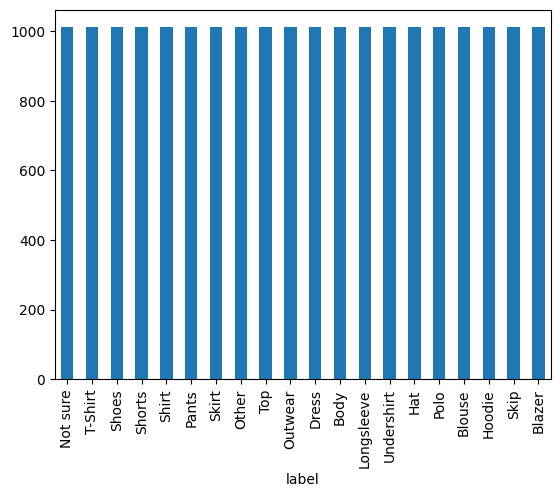

In [ ]:
# Number of images for each class after data augmentation
df_image_2['label'].value_counts().plot(kind='bar')

In [ ]:
# Train and test split
train_df_data_aug, test_df_data_aug = train_test_split(df_image_2, test_size=0.2, stratify=df_image_2["label_indx"],
random_state=7)

# train_df_data_aug, test_df_data_aug = train_test_split(df_image_2, test_size=0.2,
# random_state=7)

In [ ]:
train_df_data_aug = create_tf_dataset(train_df_data_aug)
test_df_data_aug = create_tf_dataset(test_df_data_aug)

In [ ]:
# Using vgg16 for augmented images
vgg16_transferlearning_model_data_aug = get_vgg16_transferlearning_model()
vgg16_transferlearning_model_data_aug.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ann_hidden_1 (Dense)            │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,928,660 (68.39 MB)

 Trainable params: 3,213,972 (12.26 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

vgg16_transferlearning_model_data_aug.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
metrics=['accuracy'])
vgg16_transferlearning_model_data_aug_history=vgg16_transferlearning_model_data_aug.fit(train_df_data_aug, epochs=30, validation_data=test_df_data_aug,
verbose=1, callbacks=[early_stop])

Epoch 1/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 152s 288ms/step - accuracy: 0.5648 - loss: 1.3909 - val_accuracy: 0.6325 - val_loss: 1.2251
Epoch 2/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 128s 254ms/step - accuracy: 0.6565 - loss: 1.0879 - val_accuracy: 0.6323 - val_loss: 1.2023
Epoch 3/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 128s 252ms/step - accuracy: 0.7119 - loss: 0.9123 - val_accuracy: 0.6513 - val_loss: 1.1366
Epoch 4/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 143s 283ms/step - accuracy: 0.7426 - loss: 0.8007 - val_accuracy: 0.6724 - val_loss: 1.0733
Epoch 5/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 128s 254ms/step - accuracy: 0.7704 - loss: 0.7168 - val_accuracy: 0.6711 - val_loss: 1.0920
Epoch 6/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 128s 252ms/step - accuracy: 0.7957 - loss: 0.6256 - val_accuracy: 0.6741 - val_loss: 1.1074
Epoch 7/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 127s 251ms/step - accuracy: 0.8026 - loss: 0.5963 - val_accuracy: 0.6622 - val_loss: 1.1654
Epoch 8/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 127s 251ms/step - accuracy: 0.8110 -

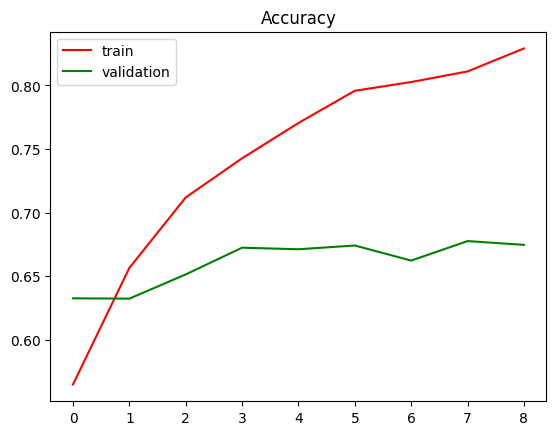

In [ ]:
draw_accuracy_plot(vgg16_transferlearning_model_data_aug_history)

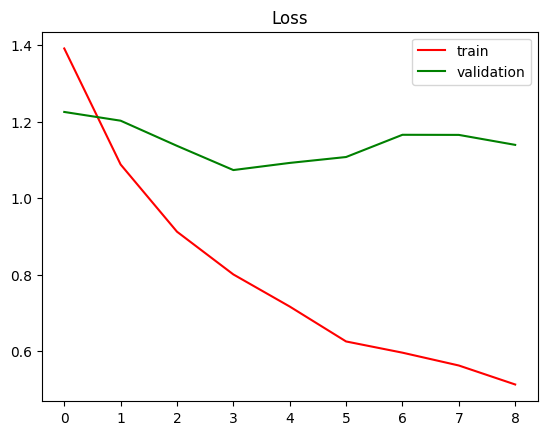

In [ ]:
draw_val_plot(vgg16_transferlearning_model_data_aug_history)

In [ ]:
print_metrics(test_df_data_aug, vgg16_transferlearning_model_data_aug,'test')

Accuracy: test 0.6723541048466865

Confusion Matrix: test
 [[ 47   9   3   4   9   5  20   6   5   3  22  11   4   8  11   1   5   2
   15  12]
 [  5 173   0   0   4   3   2   0   1   0   3   0   2   5   1   2   1   0
    0   0]
 [  1   0 189   2   0   1   0   2   1   0   1   0   0   0   4   0   0   0
    1   0]
 [  5   1   1 124   2  18  30   3   3   0   1   3   1   0   5   0   4   0
    0   2]
 [ 15   5   0   5 117   3   5   2   2   4   4   5  14   0   0   4   6   1
    5   6]
 [  2   0   0   2   1 174   6   2   1   0   2   3   1   0   4   0   0   0
    3   1]
 [  4   0   0  18   1   6 165   0   2   1   1   0   1   0   1   0   0   0
    2   0]
 [ 16   0   2   1   0   4   4 108   7   8   5  12   2   7   9   0   0   2
    9   7]
 [  2   0   2   5   0   0   6   4 171   0   0   4   0   2   2   0   2   0
    2   0]
 [ 16   0   1   4   8   3   1  13   0  70   5   2  16   0   2   0   1  12
   11  37]
 [ 18   2   2   1   1  10  30   3   6   4  93   5   1  11   3   2   4   1
    5   0]
 [  1 

In [ ]:
print_metrics(train_df_data_aug, vgg16_transferlearning_model_data_aug,'train')

Accuracy: train 0.8696834817012858

Confusion Matrix: train
 [[405  11   4  12  31  34  59  13  14  20  90   8  23   4  20   6  13   2
   24  16]
 [  4 786   0   0   2   2   3   0   1   0   4   0   7   0   0   0   0   0
    0   0]
 [  0   0 806   1   0   1   0   0   0   0   0   0   0   0   1   0   0   0
    0   0]
 [  1   0   3 713   0  25  47   0   8   0   1   0   0   0   6   0   0   0
    3   1]
 [ 46   6   1   5 610   9   5   1   1  25   8   6  33   0   6   8  10   0
   16  12]
 [  0   0   0   3   0 793   7   0   0   0   0   0   1   0   1   0   0   0
    4   0]
 [  0   0   0  13   0   2 784   0   3   0   0   0   0   1   6   0   0   0
    0   0]
 [ 16   0  13   8   0  10   8 618   9  21  10  17   1  11  14   0   0   5
   30  17]
 [  1   0   2   2   0   0  14   0 773   0   1   1   0   4   8   0   0   0
    3   0]
 [ 38   0   3   3  23   5   1  12   1 566   8   3  13   0   1   0   3  14
   35  80]
 [ 32   1   4   0   4  25  39   0   7   5 641   4   4  21   3   0   6   1
   11   1]
 [  

In [ ]:
resnet50_transferlearning_model_data_aug = get_resnet50_transferlearning_model()
resnet50_transferlearning_model_data_aug.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ann_hidden_1 (Dense)            │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,852,564 (90.99 MB)

 Trainable params: 264,852 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
resnet50_transferlearning_model_data_aug.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
metrics=['accuracy'])
# resnet50_transferlearning_model_data_aug_history=resnet50_transferlearning_model_data_aug.fit(train_df_data_aug, epochs=30, validation_data=test_df_data_aug,
# verbose=1, callbacks=[early_stop])
resnet50_transferlearning_model_data_aug_history=resnet50_transferlearning_model_data_aug.fit(train_df_data_aug, epochs=7, validation_data=test_df_data_aug,
verbose=1)

Epoch 1/7
506/506 ━━━━━━━━━━━━━━━━━━━━ 83s 143ms/step - accuracy: 0.1219 - loss: 2.8536 - val_accuracy: 0.1118 - val_loss: 2.8657
Epoch 2/7
506/506 ━━━━━━━━━━━━━━━━━━━━ 73s 143ms/step - accuracy: 0.1380 - loss: 2.8140 - val_accuracy: 0.1288 - val_loss: 2.8293
Epoch 3/7
506/506 ━━━━━━━━━━━━━━━━━━━━ 70s 139ms/step - accuracy: 0.1511 - loss: 2.7781 - val_accuracy: 0.1400 - val_loss: 2.7900
Epoch 4/7
506/506 ━━━━━━━━━━━━━━━━━━━━ 61s 121ms/step - accuracy: 0.1643 - loss: 2.7466 - val_accuracy: 0.1499 - val_loss: 2.7578
Epoch 5/7
506/506 ━━━━━━━━━━━━━━━━━━━━ 68s 135ms/step - accuracy: 0.1735 - loss: 2.7192 - val_accuracy: 0.1644 - val_loss: 2.7251
Epoch 6/7
506/506 ━━━━━━━━━━━━━━━━━━━━ 70s 138ms/step - accuracy: 0.1810 - loss: 2.6949 - val_accuracy: 0.1751 - val_loss: 2.7011
Epoch 7/7
506/506 ━━━━━━━━━━━━━━━━━━━━ 71s 139ms/step - accuracy: 0.1860 - loss: 2.6719 - val_accuracy: 0.1771 - val_loss: 2.6737


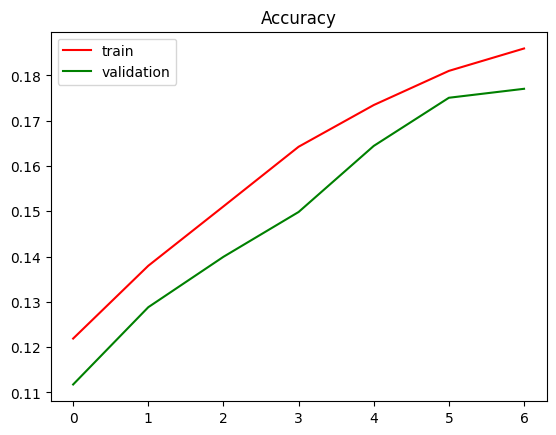

In [ ]:
draw_accuracy_plot(resnet50_transferlearning_model_data_aug_history)

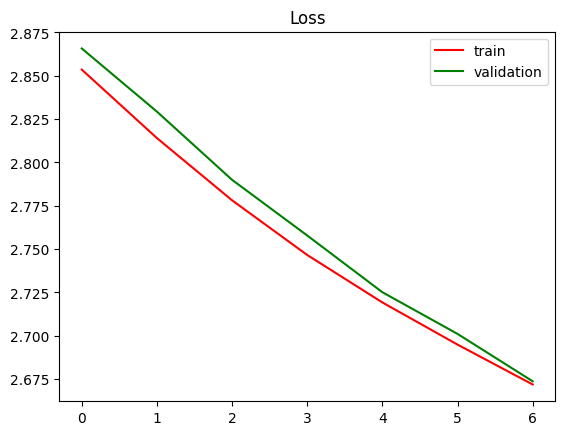

In [ ]:
draw_val_plot(resnet50_transferlearning_model_data_aug_history)

In [ ]:
print_metrics(test_df_data_aug, resnet50_transferlearning_model_data_aug,'test')

Accuracy: test 0.17705242334322452

Confusion Matrix: test
 [[  0  21   7   0   5  17  36   0   4   3   1   7  11   1   2   6  52   1
   15  13]
 [  0 111   1   0   7   1  29   0   2   1   2   3  11   0   2   4  17   0
    6   5]
 [  0   8  41   1   4  12  26   0  12   2   0   8   1   1  17   5  14   1
   27  22]
 [  0  16   5   3   7  14  42   0   8   0   3   5   7   0  10   7  37   2
   34   3]
 [  0  35   5   0  43   3  22   0   0   3   0   1  23   0   1   4  34   0
   16  13]
 [  0   2   5   0   6 105  16   0   1   0   0   5   0   0   0   1  28   1
   25   7]
 [  0  39   4   4  11   8  36   0   8   0   2   2   5   2   3   7  44   0
   15  12]
 [  0  12  13   5   8   6  25   0   4   1   1   8   3   0  14   5  43   3
   33  19]
 [  0  23   3   2  12   9  52   0  26   2   1  10   1   0  15   6  28   0
   10   2]
 [  0  29   2   0   8   9   8   0   4   3   0   8  15   0   3   7  51   3
   23  29]
 [  0  14   3   1   9  10  30   0   5   1   4   3  11   0   6   5  79   0
   16   5]
 [  0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print_metrics(train_df_data_aug, resnet50_transferlearning_model_data_aug,'train')

Accuracy: train 0.18675816023738873

Confusion Matrix: train
 [[  0  97  24   3  37  69  96   0  12  11   0  17  45   2  15  27 197   6
   86  65]
 [  0 461   6   0  27   3 109   0   8  13   4   7  38   1  14  12  77   1
   21   7]
 [  0  20 212   1  13  43  86   0  23  10   1  53   5   0  75  25  53  16
   91  82]
 [  0  75  22  13  29  60 189   0  12   3   5  20  25   0  32  35 143   6
  109  30]
 [  0 140  23   7 101  27  86   0   9   8   3  16  90   0  10  20 139   9
   82  38]
 [  0   8   4   0  18 456  84   0   2   1   1  15   5   0   5   3  93   1
   89  24]
 [  0 130  11   9  43  28 227   0  24   5   3   3  18   1  38  19 171   5
   42  32]
 [  2  54  50   8  29  34  99   0   9   8   0  29  22   0  46  24 168  19
  135  72]
 [  0 107  23   7  36  29 206   0  95   8   2  44   6   1  55  31  94   9
   49   7]
 [  0 110  31   3  44  56  50   0   9  19   0  17  77   0  13  24 190  12
   70  84]
 [  1  83  16   2  40  40 105   0  29  12  20  27  49   0  11  33 236   7
   59  39]
 [ 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
